In [1]:
# PATHS TO CHANGE
data_path = '/Users/ansonliu/Github/vision_proc_networks/data'  # path to data dir

In [2]:
import os
import requests

import torch
import torchvision.transforms as transforms

from PIL import Image, ImageOps
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_distances

import cornet

In [3]:
original_torch_load = torch.load

def cpu_torch_load(*args, **kwargs):
    kwargs['map_location'] = torch.device('cpu')
    return original_torch_load(*args, **kwargs)

torch.load = cpu_torch_load

model = cornet.cornet_s(pretrained=True)
model.eval()

print(model)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])  # TODO: conv 2 as output

/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/torch/serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


DataParallel(
  (module): Sequential(
    (V1): Sequential(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (nonlin1): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (nonlin2): ReLU(inplace=True)
      (output): Identity()
    )
    (V2): CORblock_S(
      (conv_input): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (skip): Conv2d(128, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (norm_skip): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv1): Conv2d(128, 512, kernel_size=(1, 1), str

In [4]:
import os
image_dir = Path(os.path.join(data_path, 'samples'))
image_paths = list(image_dir.glob("*"))

for image_path in image_paths:
    print(image_path)

/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7468.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7469.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7467.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7670.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7466.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7464.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7465.jpg


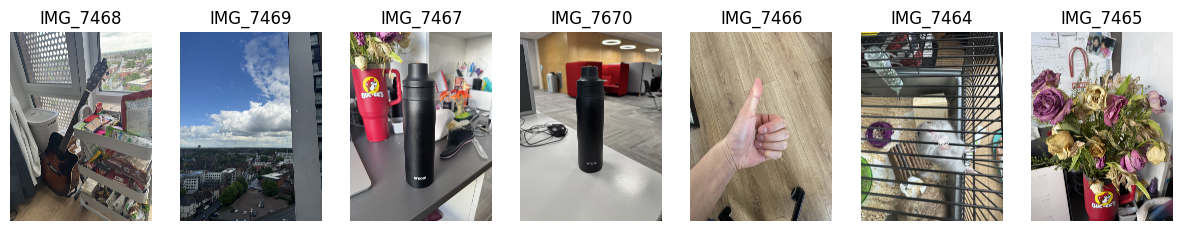

In [5]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(15,5))

for ax, path in zip(axes, image_paths):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img).convert("RGB")
    ax.imshow(img)
    ax.set_title(path.stem)
    ax.axis("off")

plt.show()

In [6]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

v1_layer = model.module.V1.register_forward_hook(get_activation("V1"))
v2_layer = model.module.V2.register_forward_hook(get_activation("V2"))
v4_layer = model.module.V4.register_forward_hook(get_activation("V4"))
it_layer = model.module.IT.register_forward_hook(get_activation("IT"))

In [7]:
img = Image.open(image_paths[3]).convert("RGB")
input_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)

# 3. Load label map
labels_json = requests.get("https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json").json()

probs = torch.nn.functional.softmax(output, dim=1)
top5_prob, top5_idx = torch.topk(probs, 5)
print("Top 5 Predictions")
for i in range(5):
    idx = str(top5_idx[0][i].item())
    label = labels_json[idx][1]
    conf = top5_prob[0][i].item()
    print(f"{i+1}: {label:20} ({conf:.2%})")
    
print("\nActivation Info")
print(f"V1 Layer Shape: {activations['V1'].shape}")

Top 5 Predictions
1: espresso_maker       (27.13%)
2: barber_chair         (10.43%)
3: dumbbell             (8.09%)
4: hand_blower          (7.07%)
5: tripod               (5.38%)

Activation Info
V1 Layer Shape: torch.Size([1, 64, 56, 56])


In [8]:
for layer_name, act in activations.items():
    print(layer_name, act.shape)

V1 torch.Size([1, 64, 56, 56])
V2 torch.Size([1, 128, 28, 28])
V4 torch.Size([1, 256, 14, 14])
IT torch.Size([1, 512, 7, 7])


In [9]:
layer_features = {
    "V1": [],
    "V2": [],
    "V4": [],
    "IT": []
}

image_names = []

for path in image_paths:

    img = Image.open(path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        _ = model(input_tensor)

    image_names.append(path.stem)

    for layer in layer_features.keys():
        feature = activations[layer]
        flattened = feature.flatten().cpu().numpy()
        layer_features[layer].append(flattened)

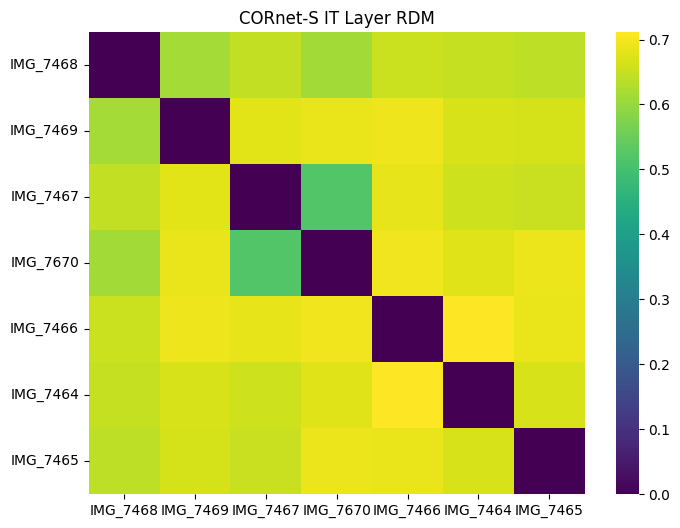

In [10]:
it_features = np.array(layer_features["IT"])
rdm = cosine_distances(it_features)

plt.figure(figsize=(8,6))
sns.heatmap(
    rdm,
    xticklabels=image_names,
    yticklabels=image_names,
    cmap="viridis"
)
plt.title("CORnet-S IT Layer RDM")
plt.show()

- similar images + 1 diff
- cornet RDM, all layers, to see how images progress
- eeg data input
- cornet-s diff models must be published to used

# EEG DATA EDA

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.stats as stats
import mne
import cv2
from numpy.linalg import lstsq


# eeg_data_path = '/Users/ansonliu/Library/CloudStorage/OneDrive-Personal/Masters/Dissertation/Example EEG Data'
eeg_data_path ='/Users/ansonliu/Downloads/Example EEG Data'

eeg_file = os.path.join(eeg_data_path, "dmrIf_mobilewalk.set")
video_file = os.path.join(eeg_data_path, "AC3.mp4")

hmax_file = os.path.join(eeg_data_path, "HMax_AC3_PCA90.mat")

In [12]:
raw = mne.io.read_raw_eeglab(str(eeg_file), preload=True)

n_pnts = raw.n_times  # 11737 samples
n_chan = raw.info['nchan']  # 67 channels
sfreq = raw.info['sfreq']  # 24 Hz

print(f"{n_chan} channels, {n_pnts} samples at {sfreq} Hz "
      f"({raw.times[-1]:.1f}s)")
print(f"Channels: {raw.ch_names[:5]} ... {raw.ch_names[-5:]}")

raw.set_channel_types({
    'x_dir': 'misc',
    'y_dir': 'misc',
    'z_dir': 'misc'
})

eeg_picks = mne.pick_types(raw.info, eeg=True)
misc_picks = mne.pick_types(raw.info, misc=True)

eeg_channels = [raw.ch_names[i] for i in eeg_picks]
accel_channels = [raw.ch_names[i] for i in misc_picks]

print(f"EEG channels: {len(eeg_channels)}")  # 64 now
print(f"Accelerometer (MISC) channels: {accel_channels}") # ['x_dir', 'y_dir', 'z_dir'] now

Reading /Users/ansonliu/Downloads/Example EEG Data/dmrIf_mobilewalk.fdt
Reading 0 ... 11736  =      0.000 ...   489.000 secs...
67 channels, 11737 samples at 24.0 Hz (489.0s)
Channels: ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ... ['F2', 'Iz', 'x_dir', 'y_dir', 'z_dir']
EEG channels: 64
Accelerometer (MISC) channels: ['x_dir', 'y_dir', 'z_dir']


/var/folders/ct/wdj1ngds73n2slpf8tkgjc540000gn/T/ipykernel_40768/1671758180.py:1: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(eeg_file), preload=True)
/var/folders/ct/wdj1ngds73n2slpf8tkgjc540000gn/T/ipykernel_40768/1671758180.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(eeg_file), preload=True)
/var/folders/ct/wdj1ngds73n2slpf8tkgjc540000gn/T/ipykernel_40768/1671758180.py:11: RuntimeWarning: The unit for channel(s) x_dir, y_dir, z_dir has changed from V to NA.
  raw.set_channel_types({


In [13]:
hmax = sio.loadmat(hmax_file)
C1 = hmax['C1'][:n_pnts]  # (11737, 273) — trimmed from 17012
C2 = hmax['C2'][:n_pnts]  # (11737, 3)   — kept for later

print(f"C1: {C1.shape}  ({C1.shape[1]} PCA components)")
print(f"C2: {C2.shape}  ({C2.shape[1]} PCA components)")

C1: (11737, 273)  (273 PCA components)
C2: (11737, 3)  (3 PCA components)


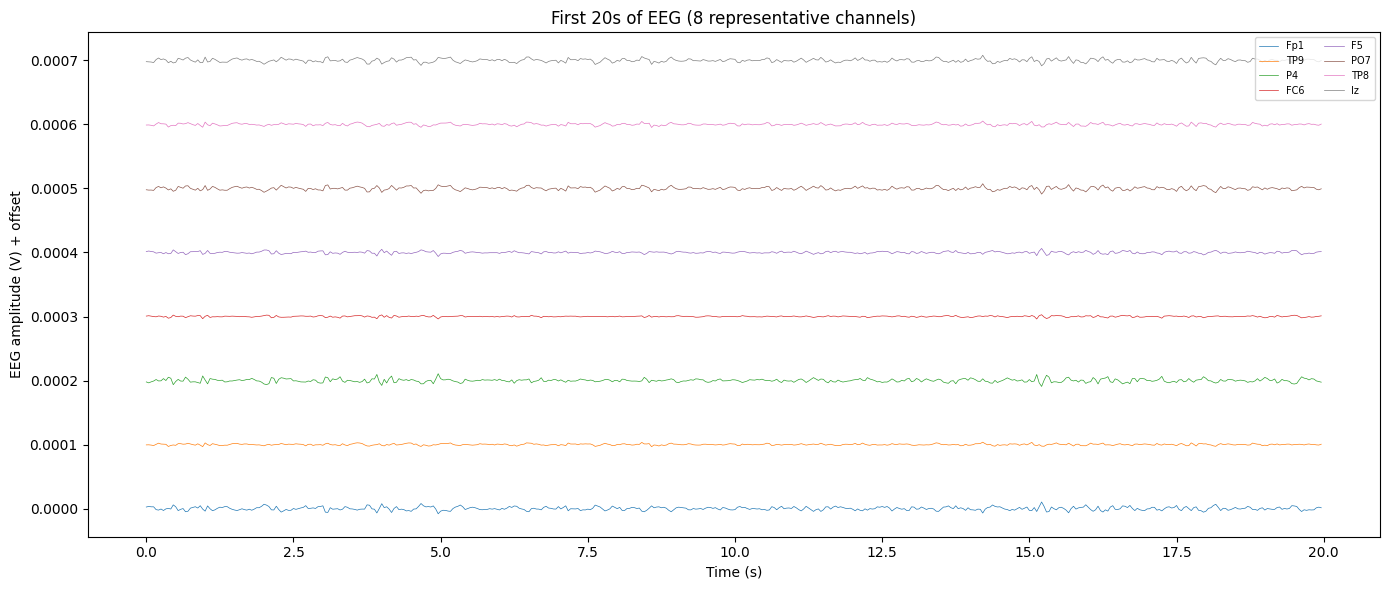

In [14]:
eeg_data = raw.get_data()  # (67, 11737), volts

fig, ax = plt.subplots(figsize=(14, 6))
t = raw.times
s_start, s_end = 0, int(20 * sfreq)  # first 20 seconds

# show 8 evenly-spaced EEG channels for readability
for i, ch_idx in enumerate(np.linspace(0, 63, 8, dtype=int)):
    offset = i * 100e-6
    ax.plot(t[s_start:s_end], eeg_data[ch_idx, s_start:s_end] + offset,
            linewidth=0.5, label=raw.ch_names[ch_idx])
ax.set_xlabel("Time (s)")
ax.set_ylabel("EEG amplitude (V) + offset")
ax.set_title("First 20s of EEG (8 representative channels)")
ax.legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

In [15]:
cap = cv2.VideoCapture(str(video_file))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Video: {n_frames} frames at {fps} fps ({n_frames/fps:.1f}s, {width}×{height})")
print(f"EEG: {raw.n_times} samples at {raw.info['sfreq']} Hz ({raw.times[-1]:.1f}s)")
print(f"HMax C1: {C1.shape[0]} feature rows")
print(f"HMax C2: {C2.shape[0]} feature rows")

# the critical sanity check
counts = {"EEG samples": raw.n_times, "Video frames": n_frames, "C1 rows": C1.shape[0], "C2 rows": C2.shape[0]}
if len(set(counts.values())) == 1:
    print("\n All counts match — sample-by-sample alignment holds.")
else:
    print(f"\n MISMATCH: {counts}")

Video: 17012 frames at 25.0 fps (680.5s, 288×480)
EEG: 11737 samples at 24.0 Hz (489.0s)
HMax C1: 11737 feature rows
HMax C2: 11737 feature rows

 MISMATCH: {'EEG samples': np.int64(11737), 'Video frames': 17012, 'C1 rows': 11737, 'C2 rows': 11737}


In [16]:
N_OFFSETS = 5

r_data = np.zeros((n_chan, N_OFFSETS))  # adjusted R squared
f_data = np.zeros((n_chan, N_OFFSETS))  # F-statistic
p_data = np.zeros((n_chan, N_OFFSETS))  # p-value

for offs in range(N_OFFSETS):
    for elec in range(n_chan):
        chanz = eeg_data[elec, offs:]  # EEG starting at sample offs
        vfeats = C1[:n_pnts - offs]  # C1 truncated to match length

        # +/- 2 SD outlier removal (per-channel, per-offset, matches MATLAB)
        thr = 2 * chanz.std() + chanz.mean()
        keep = (chanz <= thr) & (chanz >= -thr)
        chanz = chanz[keep]
        vfeats = vfeats[keep]

        # OLS with intercept
        n, p = vfeats.shape
        X = np.column_stack([np.ones(n), vfeats])
        beta, *_ = lstsq(X, chanz, rcond=None)
        y_pred = X @ beta

        # adjusted R squared — matches MATLAB's mdl.Rsquared.Adjusted
        ss_res = np.sum((chanz - y_pred) ** 2)
        ss_tot = np.sum((chanz - chanz.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

        # omnibus F-test (full model vs intercept-only) — matches mdl.devianceTest
        ms_model = (ss_tot - ss_res) / p
        ms_resid = ss_res / (n - p - 1)
        f_stat = ms_model / ms_resid if ms_resid > 0 else 0.0
        p_val = 1 - stats.f.cdf(f_stat, p, n - p - 1)

        r_data[elec, offs] = adj_r2
        f_data[elec, offs] = f_stat
        p_data[elec, offs] = p_val

    lag_ms = offs * 1000 / sfreq
    print(f"Lag {lag_ms:5.1f} ms (offs={offs+1}): "
          f"max adj-R squared={r_data[:, offs].max():.4f}, "
          f"n significant (p<0.05) = {(p_data[:, offs] < 0.05).sum()}/{n_chan}")

Lag   0.0 ms (offs=1): max adj-R squared=0.0168, n significant (p<0.05) = 3/67
Lag  41.7 ms (offs=2): max adj-R squared=0.0149, n significant (p<0.05) = 5/67
Lag  83.3 ms (offs=3): max adj-R squared=0.0150, n significant (p<0.05) = 16/67
Lag 125.0 ms (offs=4): max adj-R squared=0.0158, n significant (p<0.05) = 19/67
Lag 166.7 ms (offs=5): max adj-R squared=0.0128, n significant (p<0.05) = 29/67


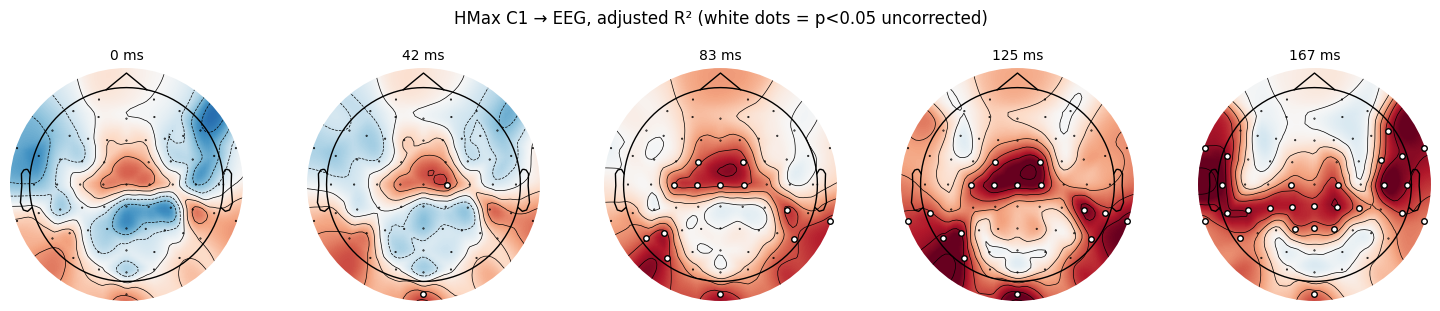

In [17]:
# select only the 64 channels with valid locations
eeg_picks = mne.pick_types(raw.info, eeg=True)
info_eeg = mne.pick_info(raw.info, eeg_picks)

# tile topomaps in a grid — adjust rows to fit N_OFFSETS
n_cols = 5
n_rows = int(np.ceil(N_OFFSETS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes_flat = axes.flatten() if N_OFFSETS > 1 else [axes]

# determine a sensible colour scale from the data (more informative than fixed ±0.02)
vmax = np.abs(r_data[eeg_picks]).max()

for offs in range(N_OFFSETS):
    ax = axes_flat[offs]
    r = r_data[eeg_picks, offs]
    p = p_data[eeg_picks, offs]
    mask = p < 0.05

    mne.viz.plot_topomap(
        r, info_eeg, axes=ax, show=False,
        vlim=(-vmax, vmax), cmap="RdBu_r",
        mask=mask,
        mask_params=dict(marker='o', markerfacecolor='w',
                         markeredgecolor='k', markersize=4),
    )
    lag_ms = offs * 1000 / sfreq
    ax.set_title(f"{lag_ms:.0f} ms", fontsize=10)

# hide unused subplots
for i in range(N_OFFSETS, len(axes_flat)):
    axes_flat[i].axis("off")

fig.suptitle("HMax C1 → EEG, adjusted R² (white dots = p<0.05 uncorrected)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

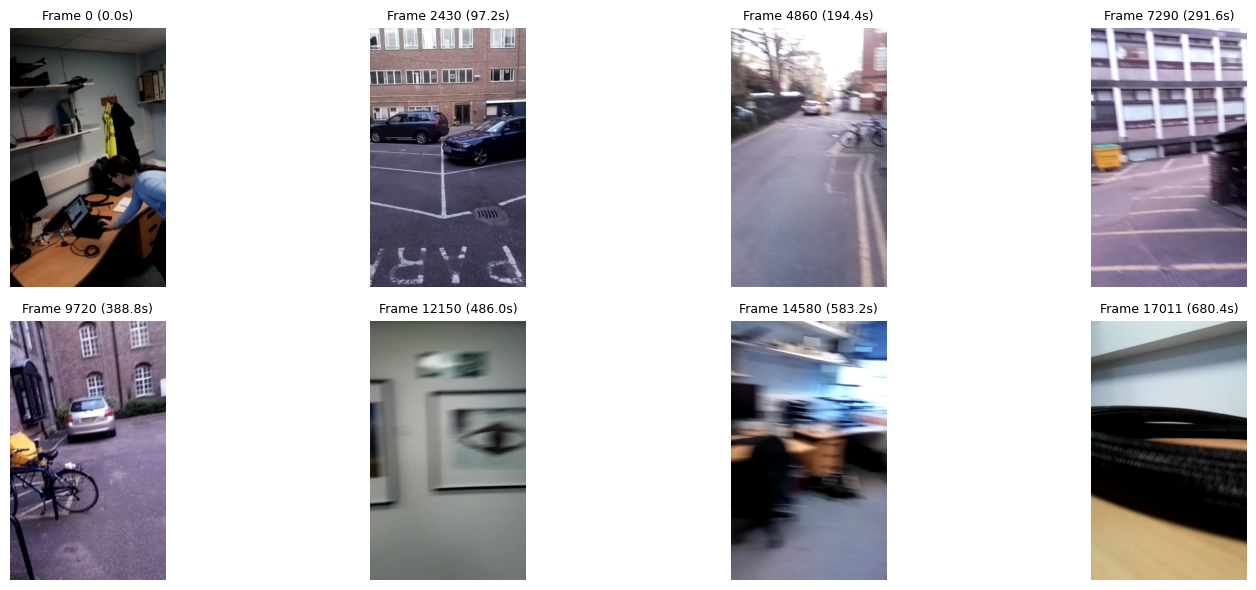

In [18]:
# view mp4
best_lag_idx = 4                              # offs=5 (167 ms) in your indexing
best_lag_ms = best_lag_idx * 1000 / sfreq
best_lag_s = best_lag_ms / 1000   # 0.167 seconds

def extract_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None)
    cap.release()
    return frames

sample_indices = np.linspace(0, n_frames - 1, 8, dtype=int)
sample_frames = extract_frames(video_file, sample_indices)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, frame, idx in zip(axes.flat, sample_frames, sample_indices):
    if frame is not None:
        ax.imshow(frame)
        ax.set_title(f"Frame {idx} ({idx/fps:.1f}s)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

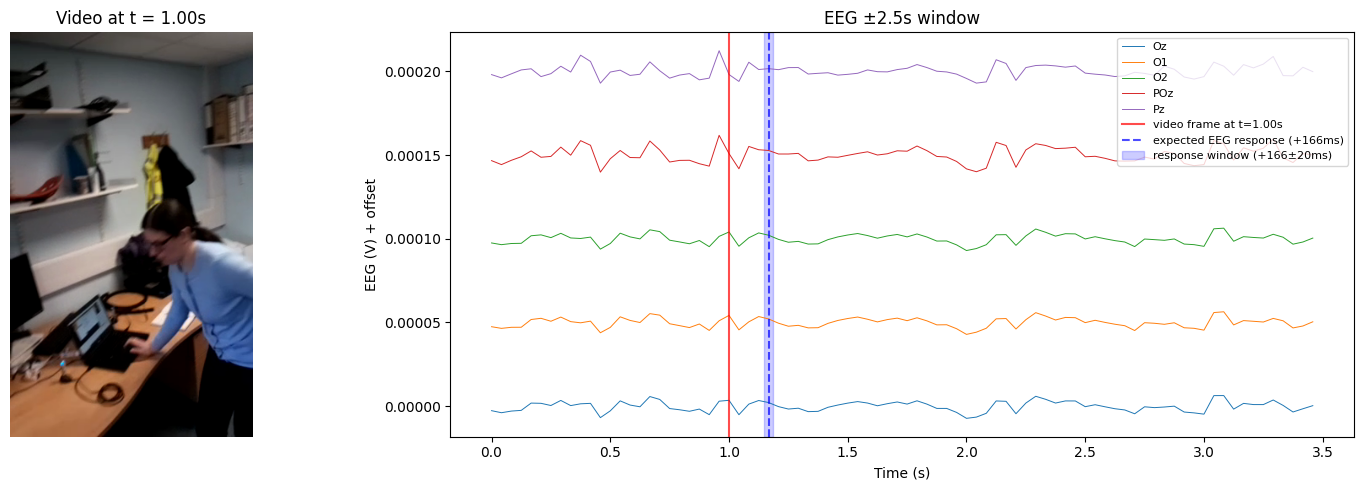

In [19]:
def show_at_time(t_sec, eeg_window=5.0):
    """
    Show the video frame at time t_sec alongside an EEG snippet centred on it.
    """
    # get video frame at this real-world time
    cap = cv2.VideoCapture(str(video_file))
    cap.set(cv2.CAP_PROP_POS_MSEC, t_sec * 1000)   # seek by time, not frame index
    ok, frame = cap.read()
    cap.release()
    if not ok:
        print(f"Could not read frame at {t_sec}s")
        return
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 2) extract the EEG window around this time
    sample = int(round(t_sec * sfreq))
    half_n = int(round(eeg_window / 2 * sfreq))
    s_lo = max(0, sample - half_n)
    s_hi = min(n_pnts, sample + half_n)

    # 3) plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                              gridspec_kw={"width_ratios": [1, 1.3]})

    axes[0].imshow(frame_rgb)
    axes[0].set_title(f"Video at t = {t_sec:.2f}s")
    axes[0].axis("off")

    # show a few occipital channels — adjust names if your montage differs
    occipital = [ch for ch in ["Oz", "O1", "O2", "POz", "Pz"] if ch in raw.ch_names]
    if not occipital:
        occipital = raw.ch_names[:5]

    times_window = raw.times[s_lo:s_hi]
    for i, ch_name in enumerate(occipital):
        ch_idx = raw.ch_names.index(ch_name)
        offset = i * 50e-6
        axes[1].plot(times_window, eeg_data[ch_idx, s_lo:s_hi] + offset,
                     linewidth=0.7, label=ch_name)

    # vertical cursor showing current time
    axes[1].axvline(t_sec, color="red", linewidth=1.5, alpha=0.7,
                    label=f"video frame at t={t_sec:.2f}s")
    # second cursor showing where the brain response to this frame appears
    axes[1].axvline(t_sec + best_lag_s, color="blue", linewidth=1.5,
                    alpha=0.7, linestyle="--",
                    label=f"expected EEG response (+{int(best_lag_ms)}ms)")
    axes[1].axvspan(t_sec + best_lag_s - 0.02,
                    t_sec + best_lag_s + 0.02,
                    color="blue", alpha=0.2,
                    label=f"response window (+{int(best_lag_ms)}±20ms)")

    
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("EEG (V) + offset")
    axes[1].set_title(f"EEG ±{eeg_window/2:.1f}s window")
    axes[1].legend(fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.show()

show_at_time(1.0)


In [20]:
from ipywidgets import interact, FloatSlider

interact(
    show_at_time,
    t_sec=FloatSlider(min=0, max=n_pnts/sfreq - 0.1, step=0.5, value=100,
                       description="Time (s)", continuous_update=True),
    eeg_window=FloatSlider(min=1, max=20, step=1, value=5,
                            description="Window (s)")
)

interactive(children=(FloatSlider(value=100.0, description='Time (s)', max=488.94166666666666, step=0.5), Floa…

<function __main__.show_at_time(t_sec, eeg_window=5.0)>

# GLMnet with EEG Data


In [21]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

best_lag_idx = 4  # 4: 167 ms

alphas = np.logspace(-3, 6, 20)
inner_cv = TimeSeriesSplit(n_splits=5)
outer_cv = TimeSeriesSplit(n_splits=5)

r_cv = np.zeros(n_chan)
alphas_chosen = np.zeros(n_chan)

for elec in tqdm(range(n_chan)):  # all channels
    chanz = eeg_data[elec, best_lag_idx:]
    vfeats = C1[:n_pnts - best_lag_idx]

    # outlier removal
    thr = 2 * chanz.std() + chanz.mean()
    keep = (chanz <= thr) & (chanz >= -thr)
    chanz = chanz[keep]
    vfeats = vfeats[keep]

    # nested CV: inner picks alpha, outer evaluates generalisation
    estimator = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas, cv=inner_cv, scoring="r2")
    )

    cv_scores = cross_val_score(
        estimator,
        vfeats,
        chanz,
        cv=outer_cv,
        scoring="r2",
    )
    r_cv[elec] = cv_scores.mean()

    # fit on full data to record chosen alpha
    estimator.fit(vfeats, chanz)

    # RidgeCV is the second step in the pipeline
    alphas_chosen[elec] = estimator.named_steps["ridgecv"].alpha_

    if elec % 10 == 0:
        print(f"channel {elec:2d}: CV R squared = {r_cv[elec]:+.4f}, "
            f"alpha = {alphas_chosen[elec]:.2g}")


  0%|          | 0/67 [00:00<?, ?it/s]/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.921103607420264e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5265650077367354e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.9349803415689166e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-c

channel  0: CV R squared = -0.0006, alpha = 1.1e+05


/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.3460388883006544e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5524280527756673e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.0238266052483596e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 h

channel 10: CV R squared = +0.0006, alpha = 3.8e+04


/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.020512254347523e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.619345546544082e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.075281623272531e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has 

...

/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.88566723031181e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6169680705502287e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.127556962885137e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has 

channel 50: CV R squared = -0.0008, alpha = 1.1e+05


/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.335569041089229e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.566011675890877e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.0596678019255705e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has

channel 60: CV R squared = -0.0020, alpha = 1.1e+05


/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.053129191803009e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5130076747027488e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.940700565863153e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has

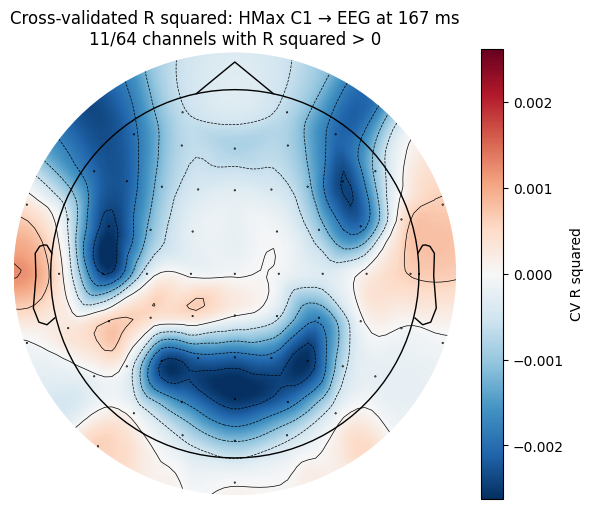

In [22]:
eeg_picks = mne.pick_types(raw.info, eeg=True)
info_eeg = mne.pick_info(raw.info, eeg_picks)

r_cv_eeg = r_cv[eeg_picks]
vmax = np.abs(r_cv_eeg).max()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im, _ = mne.viz.plot_topomap(
    r_cv_eeg, info_eeg, axes=ax, show=False,
    vlim=(-vmax, vmax), cmap="RdBu_r",
)
n_pos = (r_cv_eeg > 0).sum()
ax.set_title(f"Cross-validated R squared: HMax C1 → EEG at {best_lag_ms:.0f} ms\n"
             f"{n_pos}/{len(r_cv_eeg)} channels with R squared > 0")
plt.colorbar(im, ax=ax, fraction=0.046, label="CV R squared")
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

df = pd.DataFrame({
    "channel": info_eeg.ch_names,
    "r2": r_cv_eeg
}).sort_values("r2", ascending=False)

print(df)

   channel        r2
26    FT10  0.000653
10     CP5  0.000624
25      T8  0.000621
11     CP1  0.000482
42     CP3  0.000446
..     ...       ...
40      C5 -0.002438
59      F6 -0.002440
5      FC5 -0.002533
47     POz -0.002620
18      P4 -0.002623

[64 rows x 2 columns]


In [24]:
import sys
have = {k: (k in dir()) for k in ['model','transform','activations','eeg_data','C1','video_file','n_pnts','sfreq','n_chan','N_OFFSETS','info_eeg','eeg_picks','cv2','mne','Image','torch','np','lstsq','stats','Path','data_path']}
print(have)

{'model': True, 'transform': True, 'activations': True, 'eeg_data': True, 'C1': True, 'video_file': True, 'n_pnts': True, 'sfreq': True, 'n_chan': True, 'N_OFFSETS': True, 'info_eeg': True, 'eeg_picks': True, 'cv2': True, 'mne': True, 'Image': True, 'torch': True, 'np': True, 'lstsq': True, 'stats': True, 'Path': True, 'data_path': True}


In [25]:
import time
import torch.nn.functional as F
from sklearn.decomposition import PCA

CORNET_LAYERS = ["V1", "V2", "V4", "IT"]
BATCH_SIZE    = 32
PCA_VARIANCE  = 0.90
POOL_MODE     = "gap"

feature_cache_dir = Path(data_path) / "cornet_features"
feature_cache_dir.mkdir(parents=True, exist_ok=True)

def cache_path(layer, kind):
    if kind == "pca":
        return feature_cache_dir / f"{layer}_{POOL_MODE}_pca{int(PCA_VARIANCE * 100)}.npy"
    return feature_cache_dir / f"{layer}_{POOL_MODE}_raw.npy"

def pool_activation(act, mode="gap"):
    if mode == "gap":
        pooled = act.mean(dim=(2, 3))
    elif mode == "spatial4x4":
        pooled = F.adaptive_avg_pool2d(act, 4).flatten(1)
    else:
        raise ValueError(f"unknown pool mode: {mode}")
    return pooled.cpu().numpy()

# smoke test: 2 batches' worth of frames, check pooled shapes
model.eval()
cap = cv2.VideoCapture(str(video_file))
batch = []
for i in range(64):
    ret, frame = cap.read()
    assert ret, f"frame {i} read failed"
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    batch.append(transform(Image.fromarray(rgb)))
cap.release()
x = torch.stack(batch)
with torch.no_grad():
    _ = model(x)
print("batch tensor:", tuple(x.shape))
for layer in CORNET_LAYERS:
    print(layer, "raw act:", tuple(activations[layer].shape),
          "-> pooled:", pool_activation(activations[layer], "gap").shape)

batch tensor: (64, 3, 224, 224)
V1 raw act: (64, 64, 56, 56) -> pooled: (64, 64)
V2 raw act: (64, 128, 28, 28) -> pooled: (64, 128)
V4 raw act: (64, 256, 14, 14) -> pooled: (64, 256)
IT raw act: (64, 512, 7, 7) -> pooled: (64, 512)


In [30]:
from sklearn.linear_model import LinearRegression

def run_lag_regression(eeg_data, feature_matrix, n_offsets, sfreq, n_chan):
    n_pnts_ = feature_matrix.shape[0]
    r_data = np.zeros((n_chan, n_offsets))
    f_data = np.zeros((n_chan, n_offsets))
    p_data = np.zeros((n_chan, n_offsets))
    for offs in range(n_offsets):
        for elec in range(n_chan):
            chanz = eeg_data[elec, offs:]          # EEG starting at sample offs
            vfeats = feature_matrix[:n_pnts_ - offs]  # features trimmed to match

            # +/- 2 SD outlier removal (per channel, per offset)
            thr = 2 * chanz.std() + chanz.mean()
            keep = (chanz <= thr) & (chanz >= -thr)
            chanz, vfeats = chanz[keep], vfeats[keep]
            n, p = vfeats.shape

            # OLS fit (sklearn adds the intercept) and ordinary R squared
            model = LinearRegression().fit(vfeats, chanz)
            r2 = model.score(vfeats, chanz)

            # adjusted R squared (matches MATLAB mdl.Rsquared.Adjusted)
            adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

            # omnibus F-test, full model vs intercept-only (matches devianceTest);
            # F = (R2/p) / ((1-R2)/(n-p-1)), with the p-value from the F CDF
            f_stat = (r2 / p) / ((1 - r2) / (n - p - 1)) if r2 < 1 else 0.0
            p_val = 1 - stats.f.cdf(f_stat, p, n - p - 1)

            r_data[elec, offs] = adj_r2
            f_data[elec, offs] = f_stat
            p_data[elec, offs] = p_val
    return r_data, f_data, p_data

r_chk, f_chk, p_chk = run_lag_regression(eeg_data, C1, N_OFFSETS, sfreq, n_chan)
print(f"max adj-R2={r_chk.max():.4f} (cell-17 expected 0.0168)")
for offs in range(N_OFFSETS):
    print(f"lag {offs*1000/sfreq:5.1f} ms: max adj-R2={r_chk[:,offs].max():.4f}, n sig={(p_chk[:,offs]<0.05).sum()}/{n_chan}")

max adj-R2=0.0168 (cell-17 expected 0.0168)
lag   0.0 ms: max adj-R2=0.0168, n sig=3/67
lag  41.7 ms: max adj-R2=0.0149, n sig=5/67
lag  83.3 ms: max adj-R2=0.0150, n sig=16/67
lag 125.0 ms: max adj-R2=0.0158, n sig=19/67
lag 166.7 ms: max adj-R2=0.0128, n sig=29/67


In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from tqdm import tqdm

# best_offset=4 -> 166.7 ms at 24 Hz: the lag with the most significant electrodes
# in the linear baseline. Hardcoded for now; the data-driven choice would be
# (p_baseline < 0.05).sum(axis=0).argmax(). XGBoost only runs this one lag (10x
# fewer fits); the other lag columns are left as zeros so the cells below still run.
BEST_OFFSET = 4

# Search space + method shared by both XGBoost lag models (PCA and raw).
XGB_PARAM_DIST = {
    "n_estimators":     [100, 200],
    "max_depth":        [2, 4, 6],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [ 0.8, 1.0],
    "min_child_weight": [1, 3],
}


def tune_xgboost(X, y, n_iter=25, n_splits=3, random_state=0):
    """Randomised search over XGB_PARAM_DIST with a time-series CV; returns best params."""
    search = RandomizedSearchCV(
        XGBRegressor(n_jobs=1, verbosity=0, random_state=random_state),
        XGB_PARAM_DIST, n_iter=n_iter, cv=TimeSeriesSplit(n_splits=n_splits),
        scoring="r2", n_jobs=-1, random_state=random_state,
    )
    search.fit(X, y)
    return search.best_params_


def clean_outliers(chanz, vfeats):
    """+/- 2 SD removal on the EEG channel (identical to the linear baseline)."""
    thr = 2 * chanz.std() + chanz.mean()
    keep = (chanz <= thr) & (chanz >= -thr)
    return chanz[keep], vfeats[keep]


def run_lag_regression_gbm(eeg_data, feature_matrix, n_offsets, sfreq, n_chan,
                           pca_variance=0.95, test_frac=0.2, best_offset=BEST_OFFSET):
    """Gradient-boosted twin of run_lag_regression, with PCA-reduced features.

    Same (r_data, f_data, p_data) shapes as the baseline so the cells below run
    unchanged. Only `best_offset` (166.7 ms) is computed — that lag's column is
    filled, the rest stay zero.

    Differences from the linear baseline:
      * PCA reduces the features first (denoise + speed); `pca_variance` is the
        fraction of variance to keep.
      * a hyperparameter-tuned XGBoost ensemble replaces OLS. Tuning runs ONCE on
        the highest-variance channel at this lag, then the best params are reused.
      * R^2 is OUT-OF-SAMPLE (train on the first 1-test_frac in time, score on the
        tail), keeping the "does it capture more variance?" comparison honest.
    """
    # PCA once on the full feature matrix (unsupervised, no leakage)
    print('PCA')
    feats = PCA(n_components=pca_variance, svd_solver="full").fit_transform(feature_matrix)
    n_pnts_, n_comp = feats.shape
    offs = best_offset

    # tune once on the highest-variance channel at this lag, then reuse everywhere
    ref = int(eeg_data.var(axis=1).argmax())
    y_ref, X_ref = clean_outliers(eeg_data[ref, offs:], feats[:n_pnts_ - offs])
    print('tuning')
    best_params = tune_xgboost(X_ref, y_ref)
    print(f"XGBoost+PCA | PCA {feature_matrix.shape[1]} -> {n_comp} comps "
          f"({pca_variance:.0%} var) | lag {offs * 1000 / sfreq:.1f} ms only "
          f"| tuned on ch {ref}: {best_params}")

    r_data = np.zeros((n_chan, n_offsets))
    f_data = np.zeros((n_chan, n_offsets))
    p_data = np.zeros((n_chan, n_offsets))
    for elec in tqdm(range(n_chan)):
        chanz, vfeats = clean_outliers(eeg_data[elec, offs:], feats[:n_pnts_ - offs])
        n, p = vfeats.shape

        # chronological hold-out: train on the past, score on the future tail
        split = int(n * (1 - test_frac))
        model = XGBRegressor(**best_params, n_jobs=-1, verbosity=0, random_state=0)
        model.fit(vfeats[:split], chanz[:split])
        r2 = r2_score(chanz[split:], model.predict(vfeats[split:]))  # out-of-sample

        # same trio as the baseline so downstream masking still works.
        # r_data is the held-out R^2 (already honest, no in-sample adjustment).
        # F/p reuse the omnibus formula on the test set as an approximate
        # "is this channel predictable?" flag: R^2 <= 0 -> F = 0 -> not significant.
        dfd = (n - split) - p - 1
        f_stat = (r2 / p) / ((1 - r2) / dfd) if (0 < r2 < 1 and dfd > 0) else 0.0
        p_val = 1 - stats.f.cdf(f_stat, p, dfd) if dfd > 0 else 1.0

        r_data[elec, offs] = r2
        f_data[elec, offs] = f_stat
        p_data[elec, offs] = p_val

    print(f"  lag {offs * 1000 / sfreq:5.1f} ms (only lag run): "
          f"max R2={r_data[:, offs].max():.4f}, "
          f"n sig={(p_data[:, offs] < 0.05).sum()}/{n_chan}")
    return r_data, f_data, p_data


# Overwrites r_chk / f_chk / p_chk (the same names the cells below read) so you can
# rerun every plot/summary cell against XGBoost+PCA and compare. Rerun the baseline
# cell above to switch r_chk back to the OLS result.
r_chk, f_chk, p_chk = run_lag_regression_gbm(eeg_data, C1, N_OFFSETS, sfreq, n_chan)
print(f"\n[XGBoost+PCA] max out-of-sample R2={r_chk.max():.4f}  "
      f"(linear baseline max adj-R2 was 0.0168)")

In [ ]:
def run_lag_regression_xgb_raw(eeg_data, feature_matrix, n_offsets, sfreq, n_chan,
                               test_frac=0.2, best_offset=BEST_OFFSET):
    """Raw (no-PCA) twin of run_lag_regression_gbm.

    Identical pipeline and identical hyperparameter tuning, but the XGBoost model
    sees the FULL feature matrix instead of PCA components. Run this and the PCA
    version back to back to see what PCA buys (or costs) on held-out R^2.

    Like the PCA version, only `best_offset` (166.7 ms) is computed. Same
    (r_data, f_data, p_data) return, so the cells below run unchanged — it
    overwrites r_chk / f_chk / p_chk too.
    """
    feats = feature_matrix
    n_pnts_, n_feat = feats.shape
    offs = best_offset

    # same tuning method as the PCA version, on the raw features at this lag
    ref = int(eeg_data.var(axis=1).argmax())
    y_ref, X_ref = clean_outliers(eeg_data[ref, offs:], feats[:n_pnts_ - offs])
    best_params = tune_xgboost(X_ref, y_ref)
    print(f"XGBoost (raw) | {n_feat} features, no PCA | lag {offs * 1000 / sfreq:.1f} ms only "
          f"| tuned on ch {ref}: {best_params}")

    r_data = np.zeros((n_chan, n_offsets))
    f_data = np.zeros((n_chan, n_offsets))
    p_data = np.zeros((n_chan, n_offsets))
    for elec in range(n_chan):
        chanz, vfeats = clean_outliers(eeg_data[elec, offs:], feats[:n_pnts_ - offs])
        n, p = vfeats.shape

        split = int(n * (1 - test_frac))
        model = XGBRegressor(**best_params, n_jobs=-1, verbosity=0, random_state=0)
        model.fit(vfeats[:split], chanz[:split])
        r2 = r2_score(chanz[split:], model.predict(vfeats[split:]))  # out-of-sample

        dfd = (n - split) - p - 1
        f_stat = (r2 / p) / ((1 - r2) / dfd) if (0 < r2 < 1 and dfd > 0) else 0.0
        p_val = 1 - stats.f.cdf(f_stat, p, dfd) if dfd > 0 else 1.0

        r_data[elec, offs] = r2
        f_data[elec, offs] = f_stat
        p_data[elec, offs] = p_val

    print(f"  lag {offs * 1000 / sfreq:5.1f} ms (only lag run): "
          f"max R2={r_data[:, offs].max():.4f}, "
          f"n sig={(p_data[:, offs] < 0.05).sum()}/{n_chan}")
    return r_data, f_data, p_data


# Overwrites r_chk / f_chk / p_chk so the plot/summary cells below render the raw
# (no-PCA) XGBoost result. Compare its max R2 against the PCA version's print-out.
r_chk, f_chk, p_chk = run_lag_regression_xgb_raw(eeg_data, C1, N_OFFSETS, sfreq, n_chan)
print(f"\n[XGBoost raw] max out-of-sample R2={r_chk.max():.4f}  "
      f"(linear baseline max adj-R2 was 0.0168)")

In [27]:
# ============================================================
# Honest comparison: every model on ONE out-of-sample scale
# ============================================================
# The in-function "0.0168" anchor is IN-sample OLS, so it isn't comparable to the
# held-out XGBoost / Ridge numbers. Here all four models are scored the same way:
# a chronological 80/20 hold-out (train on the past, score on the unseen tail) at
# the best lag (167 ms). Each model uses the feature set it's actually configured
# with. This cell is standalone — it stores results_oos and does NOT touch r_chk.
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

offs = BEST_OFFSET
TEST_FRAC = 0.2


def oos_r2_per_channel(make_estimator, feature_matrix):
    """Held-out R^2 at the best lag for every channel (chronological split)."""
    n_pnts_ = feature_matrix.shape[0]
    r = np.full(n_chan, np.nan)
    for elec in range(n_chan):
        chanz, vfeats = clean_outliers(eeg_data[elec, offs:], feature_matrix[:n_pnts_ - offs])
        split = int(len(chanz) * (1 - TEST_FRAC))
        est = make_estimator()
        est.fit(vfeats[:split], chanz[:split])
        r[elec] = r2_score(chanz[split:], est.predict(vfeats[split:]))
    return r


# feature sets: raw C1 for OLS/Ridge/XGB-raw, PCA-reduced for XGB+PCA
C1_pca = PCA(n_components=0.95, svd_solver="full").fit_transform(C1)

# tune each XGBoost variant once on its own feature space (highest-variance channel)
ref = int(eeg_data.var(axis=1).argmax())
y_ref, X_raw = clean_outliers(eeg_data[ref, offs:], C1[:C1.shape[0] - offs])
_,     X_pca = clean_outliers(eeg_data[ref, offs:], C1_pca[:C1_pca.shape[0] - offs])
xgb_raw_params = tune_xgboost(X_raw, y_ref)
xgb_pca_params = tune_xgboost(X_pca, y_ref)

alphas = np.logspace(-3, 6, 20)
models = {
    "OLS":     (lambda: LinearRegression(), C1),
    "Ridge":   (lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)), C1),
    "XGB+PCA": (lambda: XGBRegressor(**xgb_pca_params, n_jobs=-1, verbosity=0, random_state=0), C1_pca),
    "XGB raw": (lambda: XGBRegressor(**xgb_raw_params, n_jobs=-1, verbosity=0, random_state=0), C1),
}

results_oos = {name: oos_r2_per_channel(make, feats) for name, (make, feats) in models.items()}

print(f"Out-of-sample R^2 at {offs * 1000 / sfreq:.1f} ms (EEG channels only):")
print(f"  {'model':8s} {'best ch':>9s} {'median':>9s} {'n>0':>8s}")
for name, r in results_oos.items():
    rr = r[eeg_picks]
    print(f"  {name:8s} {rr.max():+9.4f} {np.median(rr):+9.4f} {f'{(rr>0).sum()}/{len(rr)}':>8s}")

# bar chart: best-channel vs median-channel held-out R^2, same scale for all models
names = list(results_oos)
best = [results_oos[n][eeg_picks].max() for n in names]
med  = [np.median(results_oos[n][eeg_picks]) for n in names]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, best, 0.4, label="best channel")
ax.bar(x + 0.2, med, 0.4, label="median channel")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("out-of-sample $R^2$")
ax.set_title(f"Held-out $R^2$ at {offs * 1000 / sfreq:.1f} ms — same scale for all models\n"
             "(R^2 < 0 = worse than predicting the mean)")
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'BEST_OFFSET' is not defined

In [28]:
defined = [k for k in ['r_chk','p_chk','results','raw_features','cornet_pca'] if k in dir()]
print("defined:", defined)
if 'r_chk' in dir():
    print(f"\nPARITY (HMax C1): max adj-R2={r_chk.max():.4f}")
    for offs in range(N_OFFSETS):
        print(f"  lag {offs*1000/sfreq:5.1f} ms: max adj-R2={r_chk[:,offs].max():.4f}, n sig={(p_chk[:,offs]<0.05).sum()}/{n_chan}")
if 'results' in dir():
    print("\nCORnet layers:")
    for layer in CORNET_LAYERS:
        r,p = results[layer][0], results[layer][2]
        print(f"  {layer}: max adj-R2={r.max():.4f}, peak lag={r.max(axis=0).argmax()*1000/sfreq:.0f}ms, max n-sig={(p<0.05).sum(axis=0).max()}/{n_chan}")
if 'cornet_pca' in dir():
    print("\nPCA dims:", {l: cornet_pca[l].shape for l in CORNET_LAYERS})

defined: ['r_chk', 'p_chk']

PARITY (HMax C1): max adj-R2=0.0168
  lag   0.0 ms: max adj-R2=0.0168, n sig=3/67
  lag  41.7 ms: max adj-R2=0.0149, n sig=5/67
  lag  83.3 ms: max adj-R2=0.0150, n sig=16/67
  lag 125.0 ms: max adj-R2=0.0158, n sig=19/67
  lag 166.7 ms: max adj-R2=0.0128, n sig=29/67


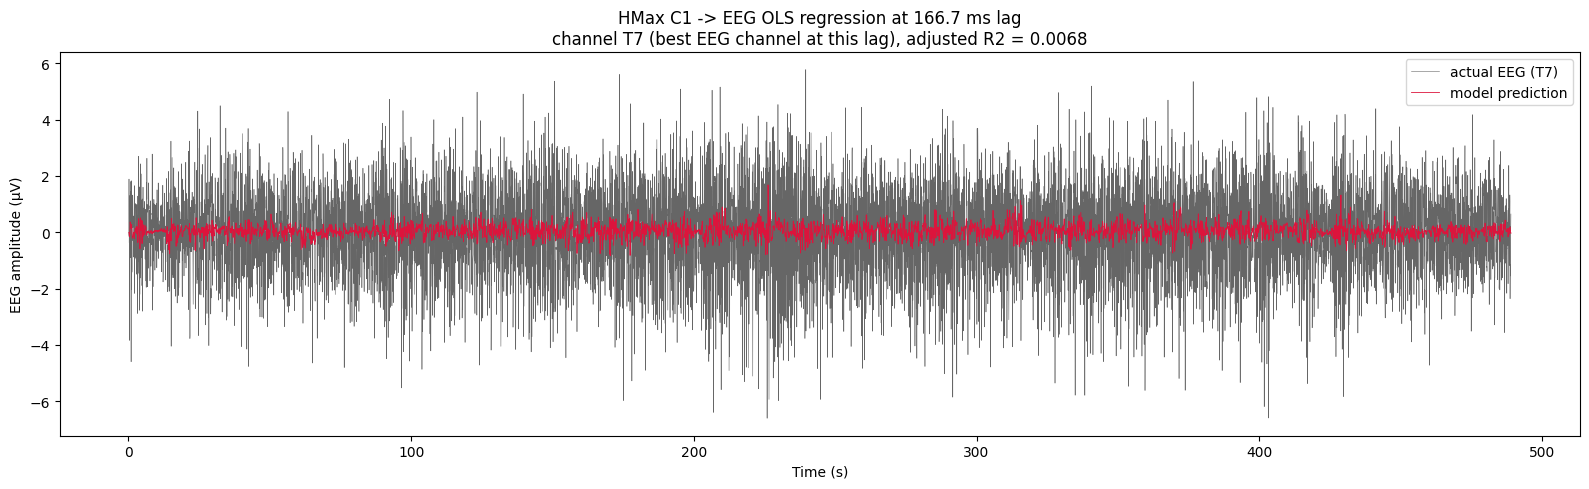

In [32]:
# Time-series: regression prediction vs actual EEG at lag 166.7 ms
lag_idx = 4                          # offs=5 -> 166.7 ms
lag_ms = lag_idx * 1000 / sfreq

# pick the best-fitting *EEG* channel at this lag (exclude accel/misc channels,
# otherwise argmax lands on y_dir/x_dir/z_dir, which trivially fit self-motion)
eeg_r = r_chk[eeg_picks, lag_idx]
best_elec = int(eeg_picks[eeg_r.argmax()])
ch_name = raw.ch_names[best_elec]

# align EEG (shifted by the lag) with the C1 predictor features
chanz = eeg_data[best_elec, lag_idx:]    # actual EEG, lag-shifted
vfeats = C1[:n_pnts - lag_idx]           # predictors
times = raw.times[lag_idx:]              # continuous time axis (s)

# fit beta on outlier-cleaned samples (matches the regression), then
# predict on every sample so the prediction line stays time-continuous
thr = 2 * chanz.std() + chanz.mean()
keep = (chanz <= thr) & (chanz >= -thr)
n, p = vfeats[keep].shape
X_fit = np.column_stack([np.ones(n), vfeats[keep]])
beta, *_ = lstsq(X_fit, chanz[keep], rcond=None)

X_all = np.column_stack([np.ones(len(vfeats)), vfeats])
y_pred = X_all @ beta

# adjusted R squared on the cleaned data (matches cell-17) for the title
ss_res = np.sum((chanz[keep] - X_fit @ beta) ** 2)
ss_tot = np.sum((chanz[keep] - chanz[keep].mean()) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# plot the FULL EEG length (lower granularity, but shows overall performance)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(times, chanz * 1e6, lw=0.4, color="0.4",
        label=f"actual EEG ({ch_name})")
ax.plot(times, y_pred * 1e6, lw=0.6, color="crimson",
        label="model prediction")
ax.set_xlabel("Time (s)")
ax.set_ylabel("EEG amplitude (µV)")
ax.set_title(f"HMax C1 -> EEG OLS regression at {lag_ms:.1f} ms lag\n"
             f"channel {ch_name} (best EEG channel at this lag), "
             f"adjusted R2 = {adj_r2:.4f}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Significant electrodes at 166.7 ms (p<0.05), grouped by region:
  Occipital  : 1 electrodes ['Iz']
  Parietal   : 10 electrodes ['CP5', 'CP1', 'Pz', 'P7', 'CP2', 'CP3', 'P1', 'P2', 'CPz', 'CP4']
  Temporal   : 10 electrodes ['FT9', 'T7', 'TP9', 'TP10', 'T8', 'FT10', 'FT7', 'TP7', 'TP8', 'FT8']
  Central    : 3 electrodes ['C1', 'C6', 'C2']
  Frontal    : 2 electrodes ['FC6', 'F8']


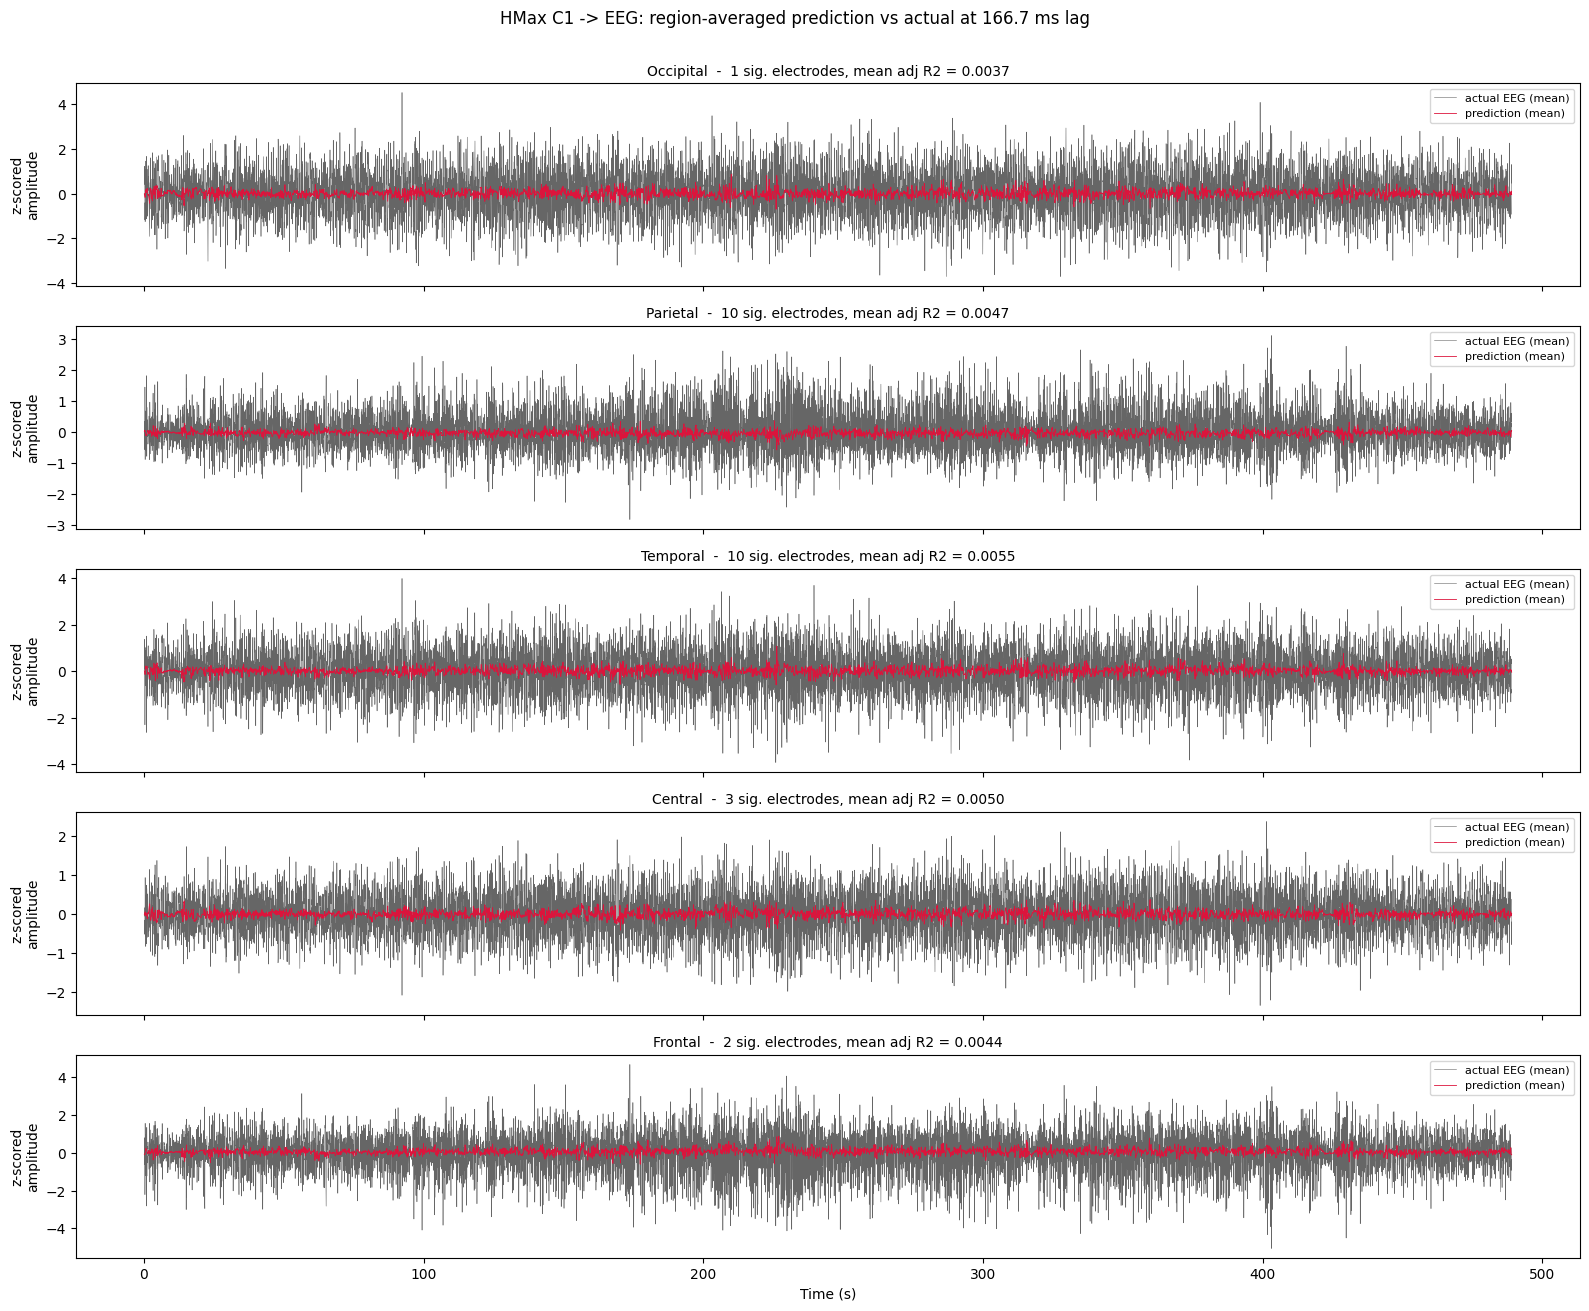

In [33]:
import re

# --- Region-averaged prediction vs actual EEG, at 166.7 ms lag ---
lag_idx = 4                          # offs=5 -> 166.7 ms
lag_ms = lag_idx * 1000 / sfreq
P_THRESH = 0.05

# map a 10-20 electrode name to a broad scalp region
def electrode_region(name):
    prefix = re.match(r"[A-Za-z]+", name).group().upper().rstrip("Z")
    region_for = {
        "FP": "Frontal", "AF": "Frontal", "F": "Frontal", "FC": "Frontal",
        "FT": "Temporal", "T": "Temporal", "TP": "Temporal",
        "C": "Central",
        "CP": "Parietal", "P": "Parietal",
        "PO": "Occipital", "O": "Occipital", "I": "Occipital",
    }
    return region_for.get(prefix, "Other")

times = raw.times[lag_idx:]
vfeats = C1[:n_pnts - lag_idx]

# fit each significant EEG electrode, collect z-scored actual + predicted by region
region_traces = {}   # region -> {"actual": [...], "pred": [...], "chans": [...], "adj_r2": [...]}

for ch in eeg_picks:                       # real EEG channels only (drops accel)
    if p_chk[ch, lag_idx] >= P_THRESH:     # keep only significant electrodes
        continue

    chanz = eeg_data[ch, lag_idx:]
    # +/- 2 SD cleaning for the fit (matches the regression)
    thr = 2 * chanz.std() + chanz.mean()
    keep = (chanz <= thr) & (chanz >= -thr)
    n, p = vfeats[keep].shape
    X_fit = np.column_stack([np.ones(n), vfeats[keep]])
    beta, *_ = lstsq(X_fit, chanz[keep], rcond=None)

    # predict on every sample so the trace stays time-continuous
    y_pred = np.column_stack([np.ones(len(vfeats)), vfeats]) @ beta

    # adjusted R squared on cleaned data
    ss_res = np.sum((chanz[keep] - X_fit @ beta) ** 2)
    ss_tot = np.sum((chanz[keep] - chanz[keep].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # z-score both traces by the ACTUAL signal's stats so channels combine
    # without polarity/scale cancellation (prediction keeps its true scale)
    mu, sd = chanz.mean(), chanz.std()
    actual_z = (chanz - mu) / sd
    pred_z = (y_pred - mu) / sd

    region = electrode_region(raw.ch_names[ch])
    d = region_traces.setdefault(
        region, {"actual": [], "pred": [], "chans": [], "adj_r2": []})
    d["actual"].append(actual_z)
    d["pred"].append(pred_z)
    d["chans"].append(raw.ch_names[ch])
    d["adj_r2"].append(adj_r2)

# order regions early -> late for readability
region_order = ["Occipital", "Parietal", "Temporal", "Central", "Frontal", "Other"]
regions = [r for r in region_order if r in region_traces]

print(f"Significant electrodes at {lag_ms:.1f} ms (p<{P_THRESH}), grouped by region:")
for r in regions:
    print(f"  {r:11s}: {len(region_traces[r]['chans'])} electrodes "
          f"{region_traces[r]['chans']}")

# plot one averaged trace pair per region across the FULL EEG length
fig, axes = plt.subplots(len(regions), 1, figsize=(16, 2.6 * len(regions)),
                         sharex=True)
axes = np.atleast_1d(axes)
for ax, r in zip(axes, regions):
    d = region_traces[r]
    mean_actual = np.mean(d["actual"], axis=0)
    mean_pred = np.mean(d["pred"], axis=0)
    ax.plot(times, mean_actual, lw=0.4, color="0.4",
            label="actual EEG (mean)")
    ax.plot(times, mean_pred, lw=0.6, color="crimson",
            label="prediction (mean)")
    ax.set_ylabel("z-scored\namplitude")
    ax.set_title(f"{r}  -  {len(d['chans'])} sig. electrodes, "
                 f"mean adj R2 = {np.mean(d['adj_r2']):.4f}", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"HMax C1 -> EEG: region-averaged prediction vs actual "
             f"at {lag_ms:.1f} ms lag", y=1.005, fontsize=12)
plt.tight_layout()
plt.show()
